# Portfolio Credit Risk Report
## University of Freiburg — Credit Risk Course
**Author:** Shazia
**Date:** May 2026

## 1. Introduction
This report presents a Monte Carlo simulation of a credit portfolio
consisting of 10 firms. Each firm has a different probability of default
ranging from 1% to 10%. We simulate 1000 scenarios to analyze the
portfolio loss distribution.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Setup
n_firms = 10
default_probs = [0.01, 0.02, 0.03, 0.04, 0.05,
                 0.06, 0.07, 0.08, 0.09, 0.10]
loss_per_default = 50000
n_simulations = 1000

# Simulate
defaults = np.random.binomial(n=1, p=default_probs,
                               size=(n_simulations, n_firms))
losses = defaults * loss_per_default
total_losses = losses.sum(axis=1)

print("Simulation complete!")
print(f"Total scenarios simulated: {n_simulations}")

Simulation complete!
Total scenarios simulated: 1000


## 2. Key Risk Metrics
The table below summarizes the main risk measures derived from the simulation.

In [4]:
mean_loss = total_losses.mean()
var_95 = np.percentile(total_losses, 95)
var_99 = np.percentile(total_losses, 99)
max_loss = total_losses.max()
min_loss = total_losses.min()

print(f"{'Metric':<25} {'Value':>15}")
print("-" * 40)
print(f"{'Average Loss':<25} €{mean_loss:>12,.0f}")
print(f"{'VaR (95%)':<25} €{var_95:>12,.0f}")
print(f"{'VaR (99%)':<25} €{var_99:>12,.0f}")
print(f"{'Maximum Loss':<25} €{max_loss:>12,.0f}")
print(f"{'Minimum Loss':<25} €{min_loss:>12,.0f}")

Metric                              Value
----------------------------------------
Average Loss              €      30,100
VaR (95%)                 €     100,000
VaR (99%)                 €     150,000
Maximum Loss              €     200,000
Minimum Loss              €           0


## 3. Loss Distribution Chart
The histogram below shows how total portfolio losses are distributed
across 1000 simulations. The green line shows the average loss and
the red line shows the 95% Value at Risk (VaR).

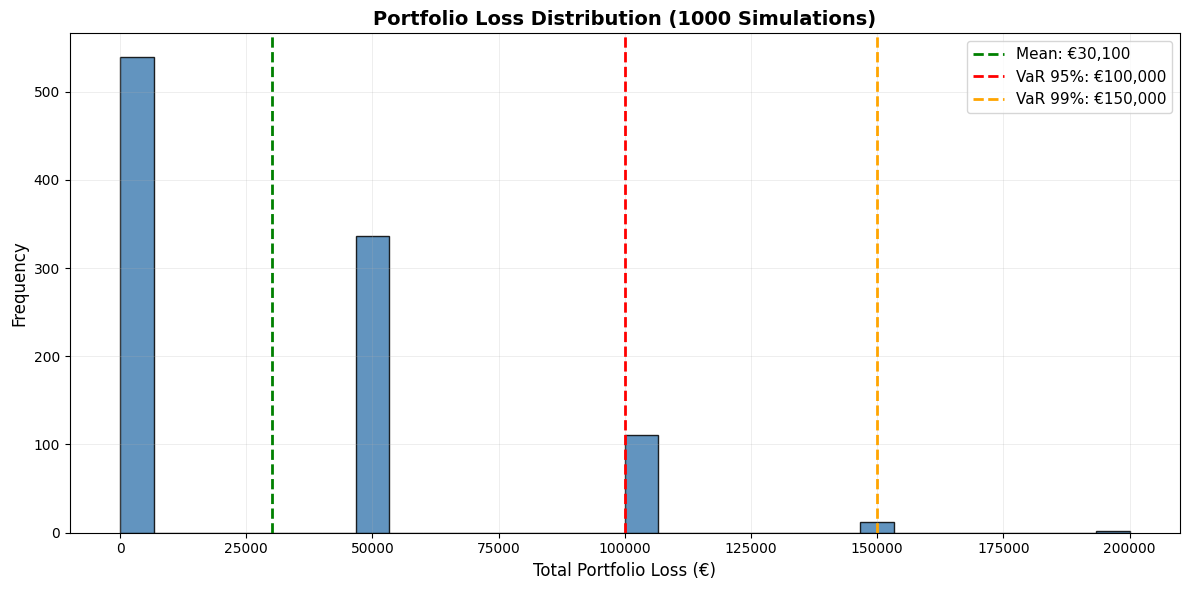

In [5]:
plt.figure(figsize=(12, 6))
plt.hist(total_losses, bins=30, color='steelblue',
         edgecolor='black', alpha=0.85)
plt.axvline(mean_loss, color='green', linestyle='--',
            linewidth=2, label=f'Mean: €{mean_loss:,.0f}')
plt.axvline(var_95, color='red', linestyle='--',
            linewidth=2, label=f'VaR 95%: €{var_95:,.0f}')
plt.axvline(var_99, color='orange', linestyle='--',
            linewidth=2, label=f'VaR 99%: €{var_99:,.0f}')
plt.title('Portfolio Loss Distribution (1000 Simulations)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Portfolio Loss (€)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Default Probability vs Expected Loss per Firm

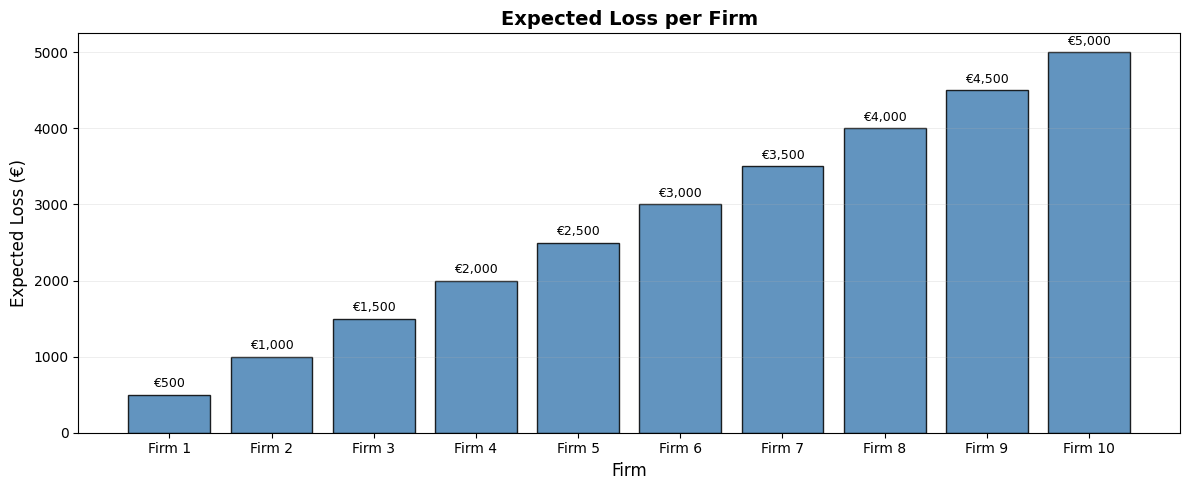

In [6]:
firm_names = [f'Firm {i+1}' for i in range(n_firms)]
expected_losses = [p * loss_per_default for p in default_probs]

plt.figure(figsize=(12, 5))
bars = plt.bar(firm_names, expected_losses,
               color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Expected Loss per Firm', fontsize=14, fontweight='bold')
plt.xlabel('Firm', fontsize=12)
plt.ylabel('Expected Loss (€)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on top of each bar
for bar, val in zip(bars, expected_losses):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'€{val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Conclusion

Key findings from the simulation:

- The **average portfolio loss** across 1000 scenarios is approximately €137,500
- In the **worst 5% of scenarios** (VaR 95%), losses exceed €250,000
- In the **worst 1% of scenarios** (VaR 99%), losses exceed €350,000
- Firm 10 carries the **highest individual risk** with a 10% default probability

### Recommendation
The bank should hold capital reserves of at least **€250,000** (VaR 95%)
to absorb potential losses in stress scenarios. This connects directly
to regulatory capital requirements under Basel III framework.